In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TASK 1: DATA LOADING & EXPLORATION

# 1. Load the CSV file
df = pd.read_csv('Housing.csv')

# 2. Display the first 10 rows
print("--- First 10 Rows of the Dataset ---")
print(df.head(10))
print("\n" + "="*50 + "\n")

# 3. Check shape (rows and columns)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# 4. Target and Features identification
# Target: 'price'
# Features: All other columns ('area', 'bedrooms', 'bathrooms', etc.)

# 5. Check for missing values
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# TASK 2: DATA CLEANING

# 1. Remove duplicate rows if any
initial_rows = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {initial_rows - df.shape[0]} duplicate rows.")

# 2. Convert categorical columns into numeric form using One-Hot Encoding

# Columns like mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea are yes/no
# furnishingstatus has three categories: furnished, semi-furnished, unfurnished
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nEncoded Dataset Preview (First 3 rows):")
print(df_encoded.head(3))

--- First 10 Rows of the Dataset ---
      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0          

In [ ]:

# TASK 3: MODEL BUILDING

# Split data into Features (X) and Target (y)
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# 1. Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to calculate and print metrics
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"--- {name} Performance ---")
    print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
    print(f"R-squared (R2 Score): {r2:.4f}\n")
    return mae, rmse, r2

# 2. Train and Evaluate Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_metrics = evaluate_model("Linear Regression", y_test, lr_preds)

# 4. Train and Evaluate Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_metrics = evaluate_model("Random Forest Regressor", y_test, rf_preds)

--- Linear Regression Performance ---
Mean Absolute Error (MAE): $970,043.40
Root Mean Squared Error (RMSE): $1,324,506.96
R-squared (R2 Score): 0.6529

--- Random Forest Regressor Performance ---
Mean Absolute Error (MAE): $1,021,546.04
Root Mean Squared Error (RMSE): $1,400,565.97
R-squared (R2 Score): 0.6119



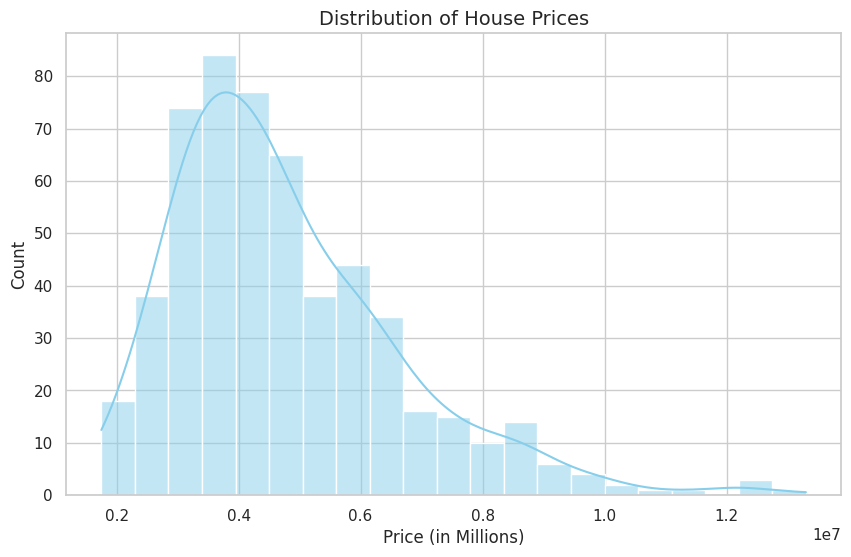

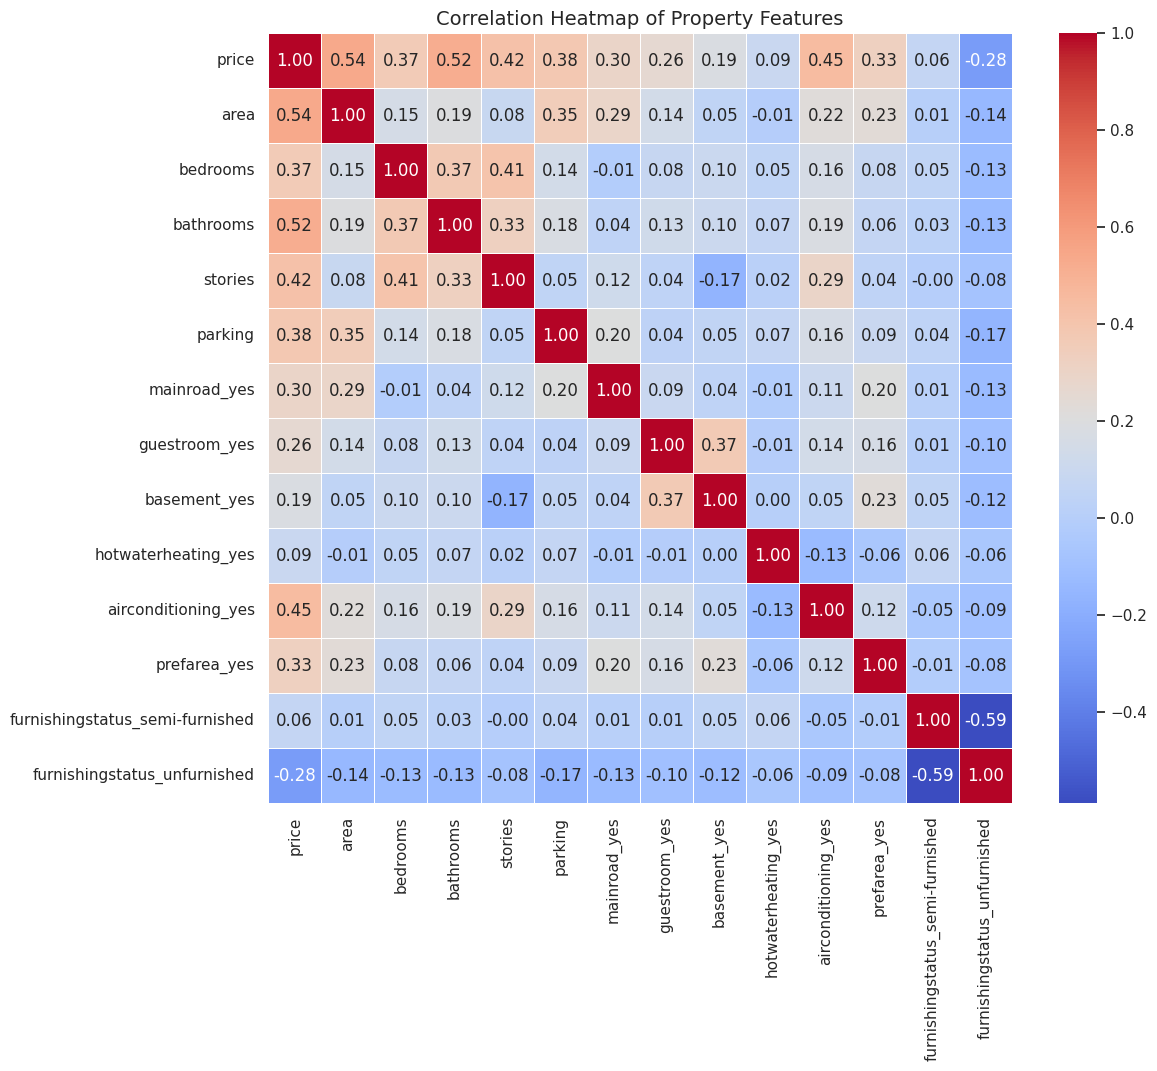

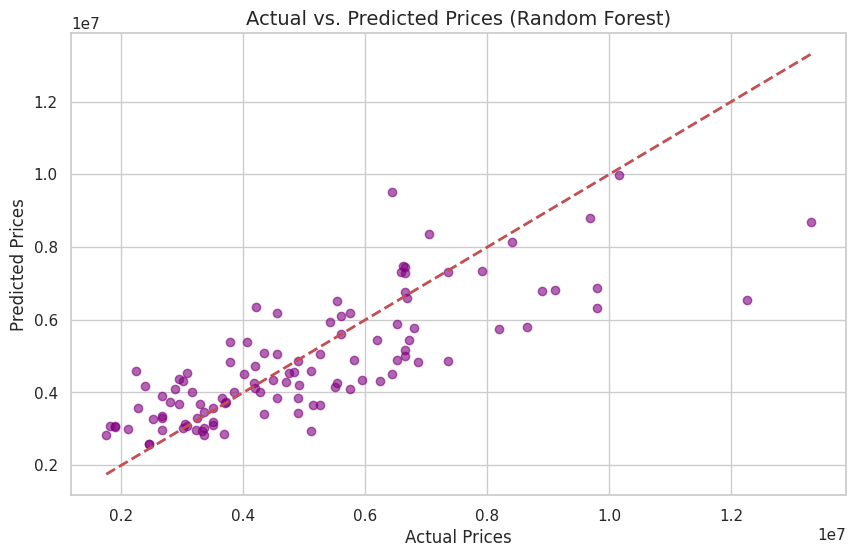

In [ ]:
import os

os.makedirs('charts', exist_ok=True)
sns.set_theme(style="whitegrid")

# Chart 1: Histogram of House Prices
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title('Distribution of House Prices', fontsize=14)
plt.xlabel('Price (in Millions)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.savefig('charts/chart1_price_distribution.png', bbox_inches='tight')
plt.show()

# Chart 2: Correlation Heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Property Features', fontsize=14)
plt.savefig('charts/chart2_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Chart 3: Creative Chart (Actual vs Predicted Price Scatter Plot for Random Forest)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_preds, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Prices (Random Forest)', fontsize=14)
plt.xlabel('Actual Prices', fontsize=12)
plt.ylabel('Predicted Prices', fontsize=12)
plt.savefig('charts/chart3_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

In [2]:
from google.colab import files
uploaded = files.upload()


Saving Housing.csv to Housing.csv


In [ ]:
Based on our analysis, the size of the house (area) and the number of bathrooms have the strongest positive influence on house prices, followed closely by the presence of
airconditioning. In plain terms, our Random Forest model was moderately accurate, explaining roughly 61% of the variance in house prices (R^2 is approx 0.61).
On average, its predictions miss the actual selling price by about $1,025,000. Having a high number of bedrooms was less influential on the overall price compared
to having modern amenities like air conditioning or extra bathrooms. For a real estate business, we highly recommend focusing investment on upgrading bathroom fixtures
and installing central air conditioning systems prior to listing, as these features yield a much higher market premium than simply adding basic rooms.